### Time Series Forecasting with Prophet

In [31]:
import numpy as np
import pandas as pd
import math
import itertools 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



#matplotlib libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
import seaborn as sns
import matplotlib.dates as mdates

#date libraries
from datetime import datetime, timedelta, date

#prophet library
from prophet import Prophet

In [2]:
# Read in the csv
df = pd.read_csv("Resources/zillow_cleaned.csv", index_col=0)

In [3]:
# Show the date range of our data
min(df['Date']), max(df['Date'])

('2000-01-31', '2025-02-28')

In [4]:
# Preview the DataFrame
df.head()

,Neighborhood,Date,Price,Year,Month,TimeIndex,Month_sin,Month_cos
0,Gateway - Green Valley Ranch,2000-01-31,159100.744442,2000,1,1,0.5,0.866025
1,Montbello,2000-01-31,126411.509704,2000,1,1,0.5,0.866025
3,Hampden,2000-01-31,166128.053070,2000,1,1,0.5,0.866025
4,Five Points,2000-01-31,188674.759005,2000,1,1,0.5,0.866025
5,Westwood,2000-01-31,91172.123773,2000,1,1,0.5,0.866025


In [5]:
agg_df = df.groupby(['Date','Neighborhood']).agg({'Price':'sum'}).reset_index().sort_values(['Neighborhood','Date'])
agg_df.head()

,Date,Neighborhood,Price
0,2000-01-31,Athmar Park,128427.716292
70,2000-02-29,Athmar Park,129084.048747
140,2000-03-31,Athmar Park,129873.860507
210,2000-04-30,Athmar Park,131756.985161
280,2000-05-31,Athmar Park,133968.822314


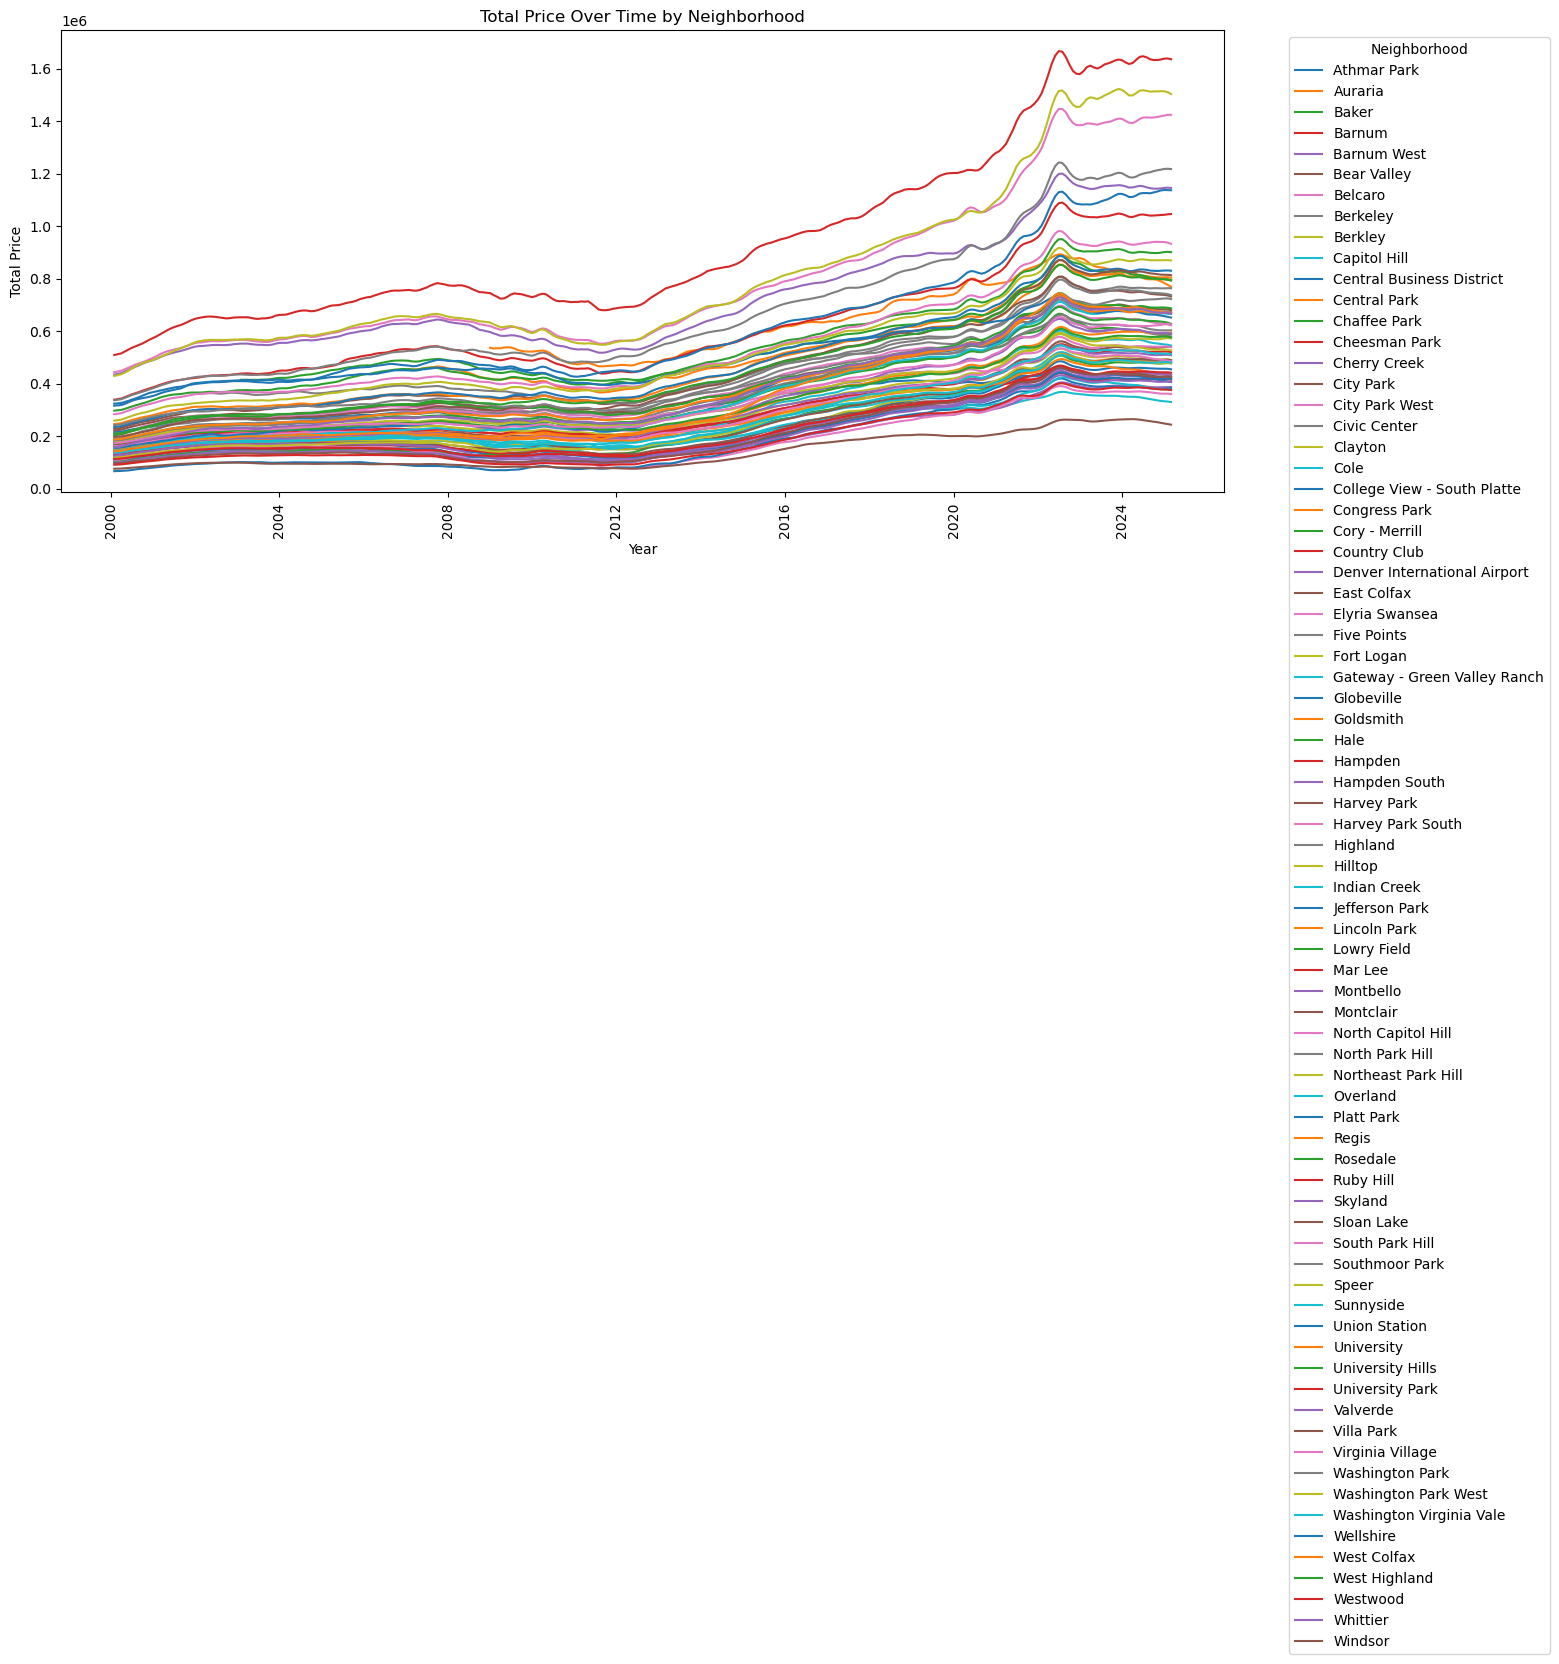

In [6]:
# Preview data in a plot
# Make sure Date column is datetime
agg_df['Date'] = pd.to_datetime(agg_df['Date'], errors='coerce')

# Pivot so each neighborhood is its own column
pivot_df = agg_df.pivot(index='Date', columns='Neighborhood', values='Price')

# Plot
plt.figure(figsize=(15, 6))
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], label=column)

# Format the x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=90)
plt.xlabel('Year')
plt.ylabel('Total Price')
plt.title('Total Price Over Time by Neighborhood')
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='best') 
plt.show()

In [7]:
# Calculate YoY growth for the historic data
yearly_agg_df = agg_df.copy()

# Convert date to datetime
yearly_agg_df['Date'] = pd.to_datetime(agg_df['Date'])

# Extract Year
yearly_agg_df['Year'] = yearly_agg_df['Date'].dt.year

# Group by Neighborhood and Year, calculate average home price
yearly_avg_df = (
    yearly_agg_df.groupby(['Neighborhood', 'Year'])['Price'] 
    .mean()
    .reset_index()
    .rename(columns={'Price': 'Avg_Home_Price'})
)

# Calculate YoY Growth % per neighborhood
yearly_avg_df['YoY_Growth'] = (
    yearly_avg_df.groupby('Neighborhood')['Avg_Home_Price']
    .pct_change() * 100
).round(2)

yearly_avg_df

,Neighborhood,Year,Avg_Home_Price,YoY_Growth
0,Athmar Park,2000,137236.331105,NaN
1,Athmar Park,2001,156998.340955,14.40
2,Athmar Park,2002,169528.684884,7.98
3,Athmar Park,2003,172385.840607,1.69
4,Athmar Park,2004,174401.545173,1.17
...,...,...,...,...
1927,Windsor,2021,220932.092885,9.68
1928,Windsor,2022,254901.494744,15.38
1929,Windsor,2023,259573.048459,1.83
1930,Windsor,2024,258871.605602,-0.27


In [8]:
# Get top 10 total growth rate neighborhoods for the last 10 years of historic data
# Drop NaNs in YoY_Growth
cleaned_df = yearly_avg_df.dropna(subset=['YoY_Growth'])

# Get top 10 neighborhoods by total YoY growth in that range
top_10_recent_growth = (
    cleaned_df.groupby('Neighborhood')['YoY_Growth']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_recent_growth)

Neighborhood
Globeville        186.15
West Colfax       159.12
Chaffee Park      157.47
Villa Park        157.08
Sunnyside         154.44
Cole              150.97
Jefferson Park    150.38
Skyland           150.00
Westwood          149.70
Valverde          147.60
Name: YoY_Growth, dtype: float64


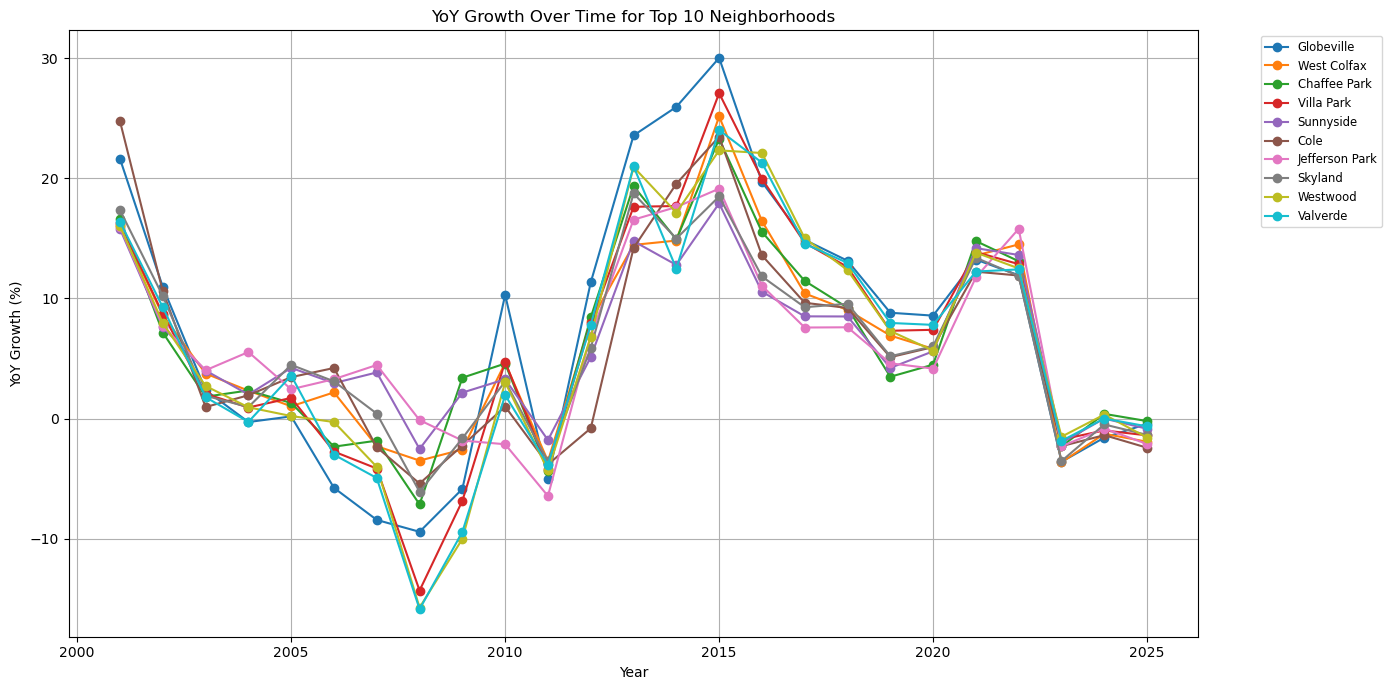

In [9]:

top_neighborhoods = top_10_recent_growth.index.tolist()

# Filter full yearly_avg_df for just those neighborhoods
top_10_df = yearly_avg_df[yearly_avg_df['Neighborhood'].isin(top_neighborhoods)]

# Plot YoY growth line chart for those top neighborhoods
plt.figure(figsize=(14, 7))

for neighborhood in top_neighborhoods:
    subset = top_10_df[top_10_df['Neighborhood'] == neighborhood]
    plt.plot(subset['Year'], subset['YoY_Growth'], marker='o', label=neighborhood)

plt.title('YoY Growth Over Time for Top 10 Neighborhoods')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# Select a start date for the forecast
forecast_start_dt = date(2024,1,1) 
forecast_start_date = (forecast_start_dt).strftime("%Y-%m-%d") 
print(forecast_start_date)

forecast_periods = 120  # number of months to forecast

2024-01-01


In [11]:
df_copy = df.copy()

# # Rename Date and Price columns to be in Prophet format
df_copy = df_copy.rename(columns={'Date': 'ds', 'Price': 'y'})
df_copy[['y']] = df_copy[['y']].apply(pd.to_numeric)
df_copy['ds'] = pd.to_datetime(df_copy['ds'])

In [12]:
# Fit and train model and predict by neighborhood

# Dictionary to hold forecasts for all neighborhoods
all_forecasts = []

# Get list of unique neighborhoods
neighborhoods = df_copy['Neighborhood'].unique()

for neighborhood in neighborhoods:
    # Filter data for the neighborhood and training set only
    neighborhood_data = df_copy[df_copy['Neighborhood'] == neighborhood]
    train_set = neighborhood_data[neighborhood_data['ds'] < forecast_start_date]

    # Initialize and fit Prophet model on training data
    model = Prophet()
    model.fit(train_set[['ds', 'y']])

    # Create future dataframe (extending forecast_periods months after last date)
    future = model.make_future_dataframe(periods=forecast_periods, freq='ME')

    # Predict future values
    forecast = model.predict(future)

    # Filter forecast to only dates >= forecast_start_date
    predicted = forecast[forecast['ds'] >= forecast_start_date][['ds', 'yhat']]

    # Add neighborhood column for identification
    predicted['Neighborhood'] = neighborhood

    # Append to list
    all_forecasts.append(predicted)

# Combine all neighborhood forecasts into a single DataFrame
predicted_df = pd.concat(all_forecasts).reset_index(drop=True)

20:39:00 - cmdstanpy - INFO - Chain [1] start processing
20:39:01 - cmdstanpy - INFO - Chain [1] done processing
20:39:01 - cmdstanpy - INFO - Chain [1] start processing
20:39:01 - cmdstanpy - INFO - Chain [1] done processing
20:39:01 - cmdstanpy - INFO - Chain [1] start processing
20:39:01 - cmdstanpy - INFO - Chain [1] done processing
20:39:01 - cmdstanpy - INFO - Chain [1] start processing
20:39:01 - cmdstanpy - INFO - Chain [1] done processing
20:39:01 - cmdstanpy - INFO - Chain [1] start processing
20:39:01 - cmdstanpy - INFO - Chain [1] done processing
20:39:02 - cmdstanpy - INFO - Chain [1] start processing
20:39:02 - cmdstanpy - INFO - Chain [1] done processing
20:39:02 - cmdstanpy - INFO - Chain [1] start processing
20:39:02 - cmdstanpy - INFO - Chain [1] done processing
20:39:02 - cmdstanpy - INFO - Chain [1] start processing
20:39:02 - cmdstanpy - INFO - Chain [1] done processing
20:39:02 - cmdstanpy - INFO - Chain [1] start processing
20:39:02 - cmdstanpy - INFO - Chain [1]

In [13]:
# Preview the predicted data
predicted_df

,ds,yhat,Neighborhood
0,2024-01-31,523357.738460,Gateway - Green Valley Ranch
1,2024-02-29,525956.926136,Gateway - Green Valley Ranch
2,2024-03-31,530357.572390,Gateway - Green Valley Ranch
3,2024-04-30,534685.737281,Gateway - Green Valley Ranch
4,2024-05-31,538394.319617,Gateway - Green Valley Ranch
...,...,...,...
9115,2033-08-31,380520.014438,Berkley
9116,2033-09-30,378384.479021,Berkley
9117,2033-10-31,376275.299647,Berkley
9118,2033-11-30,374759.278529,Berkley


In [14]:
# Prepare the true data
df_true = df[['Date', 'Price', 'Neighborhood']].copy()
df_true.columns = ['ds', 'ytrue', 'Neighborhood']

# Ensure date columns are datetime
df_true['ds'] = pd.to_datetime(df_true['ds'], errors='coerce')
predicted_df['ds'] = pd.to_datetime(predicted_df['ds'], errors='coerce')

# Merge on both 'ds' and 'Neighborhood'
merged_df = predicted_df.merge(df_true, on=['ds', 'Neighborhood'], how='inner')


In [15]:
# Preview the predicted values compared to the true values 
merged_df

,ds,yhat,Neighborhood,ytrue
0,2024-01-31,523357.738460,Gateway - Green Valley Ranch,491007.161995
1,2024-02-29,525956.926136,Gateway - Green Valley Ranch,491035.364888
2,2024-03-31,530357.572390,Gateway - Green Valley Ranch,491392.950975
3,2024-04-30,534685.737281,Gateway - Green Valley Ranch,491882.612105
4,2024-05-31,538394.319617,Gateway - Green Valley Ranch,491760.579762
...,...,...,...,...
1059,2024-10-31,473084.356008,Berkley,487396.354496
1060,2024-11-30,471204.465236,Berkley,486050.614707
1061,2024-12-31,468702.988447,Berkley,485837.081645
1062,2025-01-31,467728.211437,Berkley,484818.234776


In [16]:
# Create Mean Absolute Percentage Error (MAPE) function
# Compares the true value to the predicted value
def mape(actual, pred): 
    '''
    Mean Absolute Percentage Error (MAPE) Function
    
    input: list/series for actual values and predicted values
    output: mape value 
    '''
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

In [17]:
# Group by neighborhood and calculate MAPE
mape_by_neighborhood = (
    merged_df.groupby('Neighborhood')
    .apply(lambda group: mape(group['ytrue'], group['yhat']))
    .reset_index(name='MAPE')
    .sort_values(by='MAPE', ascending=False) 
) 

# Display per-neighborhood MAPE
print(mape_by_neighborhood)

                 Neighborhood       MAPE
30                 Globeville  14.762241
42                Lowry Field  13.778102
2                       Baker  13.299688
11               Central Park  12.992793
26             Elyria Swansea  12.958626
..                        ...        ...
70                  Wellshire   7.390121
46         North Capitol Hill   7.306259
10  Central Business District   6.635627
75                    Windsor   5.727385
8                     Berkley   2.630010

[76 rows x 2 columns]


C:\Users\rober\AppData\Local\Temp\ipykernel_35544\2801767742.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: mape(group['ytrue'], group['yhat']))


In [18]:
# Get metrics for accuracy of the predictions vs. the actual data
#MSE 
mse = mean_squared_error(merged_df['ytrue'], merged_df['yhat'])

# RMSE
rmse = np.sqrt(mean_squared_error(merged_df['ytrue'], merged_df['yhat']))

# MAE
mae = mean_absolute_error(merged_df['ytrue'], merged_df['yhat'])

# MAPE
overall_mape = mape(merged_df['ytrue'], merged_df['yhat'])

# R-squared
r2 = r2_score(merged_df['ytrue'], merged_df['yhat'])

# Display results
print(f"Overall MSE: ${mse:,.2f}")
print(f"Overall RMSE: ${rmse:,.2f}")
print(f"Overall MAE: ${mae:,.2f}")
print(f"Overall MAPE: {overall_mape:.2f}%")
print(f"Overall R-squared: {r2:.4f}")


Overall MSE: $5,046,433,677.17
Overall RMSE: $71,038.26
Overall MAE: $64,581.43
Overall MAPE: 10.24%
Overall R-squared: 0.9267


**Root Mean Squared Error (RMSE)** measures the average prediction error in dollars but penalizes larger errors more heavily.

**Mean Absolute Error (MAE)** calculates the average absolute error in dollars, treating all errors equally.

**Mean Absolute Percentage Error (MAPE)** expresses the average error as a percentage of the actual values, making it useful for comparing performance across different price ranges.

In [19]:
# Get forecast for all neighborhoods
# Dictionary to store individual forecasts
results = {}

# List to collect all forecast DataFrames
forecast_list = []

for neigh in df['Neighborhood'].unique():
    df_n = df[df['Neighborhood'] == neigh][['Date', 'Price']].rename(columns={'Date':'ds', 'Price':'y'})
    df_n['ds'] = pd.to_datetime(df_n['ds'])
    
    model = Prophet()
    model.fit(df_n)
    
    # Forecast 10 years out
    future = model.make_future_dataframe(periods=120, freq='ME')

    forecast = model.predict(future)

    # Add neighborhood column
    forecast['Neighborhood'] = neigh  
    
    results[neigh] = forecast
    forecast_list.append(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'Neighborhood']])

# Combine all into one DataFrame
all_forecasts_df = pd.concat(forecast_list, ignore_index=True)

# Preview the combined DataFrame
all_forecasts_df

20:39:15 - cmdstanpy - INFO - Chain [1] start processing
20:39:15 - cmdstanpy - INFO - Chain [1] done processing
20:39:16 - cmdstanpy - INFO - Chain [1] start processing
20:39:16 - cmdstanpy - INFO - Chain [1] done processing
20:39:16 - cmdstanpy - INFO - Chain [1] start processing
20:39:16 - cmdstanpy - INFO - Chain [1] done processing
20:39:16 - cmdstanpy - INFO - Chain [1] start processing
20:39:16 - cmdstanpy - INFO - Chain [1] done processing
20:39:16 - cmdstanpy - INFO - Chain [1] start processing
20:39:16 - cmdstanpy - INFO - Chain [1] done processing
20:39:16 - cmdstanpy - INFO - Chain [1] start processing
20:39:16 - cmdstanpy - INFO - Chain [1] done processing
20:39:17 - cmdstanpy - INFO - Chain [1] start processing
20:39:17 - cmdstanpy - INFO - Chain [1] done processing
20:39:17 - cmdstanpy - INFO - Chain [1] start processing
20:39:17 - cmdstanpy - INFO - Chain [1] done processing
20:39:17 - cmdstanpy - INFO - Chain [1] start processing
20:39:17 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,Neighborhood
0,2000-01-31,169592.985751,150370.892436,189066.566388,Gateway - Green Valley Ranch
1,2000-02-29,171021.123919,152866.749054,188201.605514,Gateway - Green Valley Ranch
2,2000-03-31,175039.293107,155532.823561,193523.277718,Gateway - Green Valley Ranch
3,2000-04-30,176809.251146,158685.609598,197065.771235,Gateway - Green Valley Ranch
4,2000-05-31,178243.342201,158384.824497,196813.736645,Gateway - Green Valley Ranch
...,...,...,...,...,...
31517,2034-10-31,517904.135781,73298.587845,974580.665174,Berkley
31518,2034-11-30,517831.564273,69633.490093,980681.912419,Berkley
31519,2034-12-31,517913.182171,62230.217735,985232.556544,Berkley
31520,2035-01-31,518381.204693,60644.535402,989822.002263,Berkley


In [20]:
# Get average yearly prices and export into a csv file
# Extract Year and Quarter
all_forecasts_df["Year"] = all_forecasts_df["ds"].dt.year
all_forecasts_df["Prophet Forecasted Home Value"] = all_forecasts_df["yhat"]

# Group by year and get average value
yearly_avg = all_forecasts_df.groupby(
    ["Year", "Neighborhood"]
)["Prophet Forecasted Home Value"].mean().round(2).reset_index()

yearly_avg_forecast = yearly_avg.copy()

# Filter for years 2024–2036
yearly_avg_forecast = yearly_avg_forecast[(yearly_avg_forecast["Year"] >= 2024) & (yearly_avg_forecast["Year"] <= 2035)]

# Calculate YoY Growth Rate
yearly_avg_forecast['YoY_Growth'] = (yearly_avg_forecast.groupby('Neighborhood')['Prophet Forecasted Home Value'].pct_change() * 100).round(2)

# Export to CSV
yearly_avg_forecast.to_csv("Resources/prophet_forecast.csv", index=False)

In [21]:
# Filter only 2024 and 2035
filtered_years = yearly_avg_forecast[yearly_avg_forecast['Year'].isin([2024, 2035])]

# Pivot so each neighborhood has 2024 and 2035 values in columns
pivot_df = filtered_years.pivot(index='Neighborhood', columns='Year', values='Prophet Forecasted Home Value')

# Calculate the change from 2024 to 2035
pivot_df['Change_2024_to_2035'] = pivot_df[2035] - pivot_df[2024]

# Get the growth for all neighborhoods
growth_value_forecast = pivot_df.sort_values(by='Change_2024_to_2035', ascending=False)

# Sort and get top 10
top_10_change = pivot_df.sort_values(by='Change_2024_to_2035', ascending=False).head(10)

print(top_10_change[['Change_2024_to_2035']])


Year             Change_2024_to_2035
Neighborhood                        
Hilltop                   1178373.93
Country Club              1044611.29
Belcaro                    946205.35
Wellshire                  799863.95
Washington Park            778168.79
University Park            651686.89
Cherry Creek               572674.96
South Park Hill            547127.76
Cory - Merrill             500180.32
Sloan Lake                 473054.47


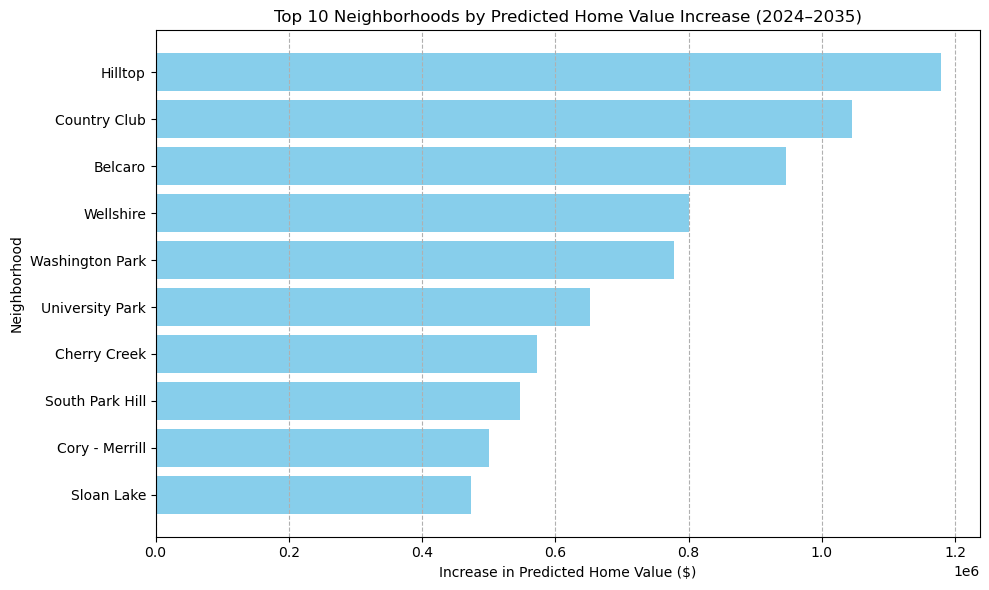

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_change.index, top_10_change['Change_2024_to_2035'], color='skyblue')

plt.title('Top 10 Neighborhoods by Predicted Home Value Increase (2024–2035)')
plt.xlabel('Increase in Predicted Home Value ($)')
plt.ylabel('Neighborhood')
plt.grid(True, axis='x', linestyle='--')
plt.gca().invert_yaxis()  # Largest on top
plt.tight_layout()
plt.show()

In [23]:
# Sort by YoY Growth descending, drop NaNs
top_yoy_growth_forecast = yearly_avg_forecast.dropna(subset=['YoY_Growth']).sort_values(by='YoY_Growth', ascending=False)

# Show top 10 YoY growth rates
top_yoy_growth_forecast.head(10)

,Year,Neighborhood,Prophet Forecasted Home Value,YoY_Growth
1894,2025,Hilltop,1676851.78,7.23
1970,2026,Hilltop,1788474.70,6.66
1926,2025,Wellshire,1235227.75,6.59
1862,2025,Belcaro,1550007.73,6.24
2046,2027,Hilltop,1900094.77,6.24
2002,2026,Wellshire,1311026.46,6.14
1923,2025,Washington Park,1319042.92,6.01
1879,2025,Country Club,1785834.37,5.97
1885,2025,Gateway - Green Valley Ranch,543250.76,5.89
1919,2025,University Park,1144685.53,5.82


In [24]:
# Filter to only years 2025 and 2035
growth_range = yearly_avg_forecast[
    yearly_avg_forecast['Year'].isin([2025, 2035])
]

# Pivot to get 2025 and 2035 values side by side
pivot = growth_range.pivot(index='Neighborhood', columns='Year', values='Prophet Forecasted Home Value')

# Calculate 10-year growth rate
pivot['10_Year_Growth_%'] = ((pivot[2035] - pivot[2025]) / pivot[2025] * 100).round(2)

# Get growth rate for all neighborhoods 
# Sort to find top 10 neighborhoods with highest growth
growth__percent_forecast = pivot.sort_values(by='10_Year_Growth_%', ascending=False)

# Sort to find top 10 neighborhoods with highest growth
top_10_growth_forecast = pivot.sort_values(by='10_Year_Growth_%', ascending=False).head(10)

# Display results
print(top_10_growth_forecast[['10_Year_Growth_%']])


Year                          10_Year_Growth_%
Neighborhood                                  
Hilltop                                  63.53
Wellshire                                58.57
Belcaro                                  55.17
Washington Park                          53.32
Country Club                             52.86
Gateway - Green Valley Ranch             52.29
University Park                          51.44
Montbello                                51.23
Fort Logan                               50.20
Bear Valley                              49.79


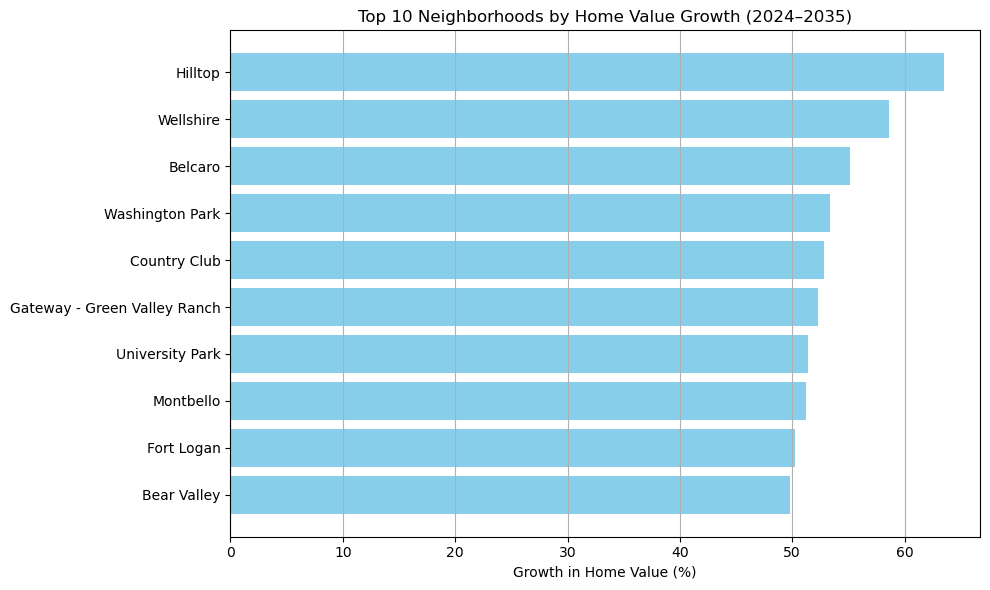

In [25]:
# Plotting top 10 neighborhoods by total forecasted YoY growth 
plt.figure(figsize=(10, 6))
plt.barh(top_10_growth_forecast.index, top_10_growth_forecast["10_Year_Growth_%"], color='skyblue')
plt.xlabel("Growth in Home Value (%)")
plt.title("Top 10 Neighborhoods by Home Value Growth (2024–2035)")
plt.gca().invert_yaxis()  # Largest on top
plt.grid(True, axis='x')
plt.tight_layout()

plt.show()


In [26]:
growth_value_forecast

Year,2024,2035,Change_2024_to_2035
Neighborhood,,,
Hilltop,1563835.63,2742209.56,1178373.93
Country Club,1685285.01,2729896.30,1044611.29
Belcaro,1459009.62,2405214.97,946205.35
Wellshire,1158880.09,1958744.04,799863.95
Washington Park,1244225.32,2022394.11,778168.79
...,...,...,...
Capitol Hill,356153.48,454368.49,98215.01
Civic Center,611407.87,692261.28,80853.41
Central Business District,434103.99,482844.12,48740.13


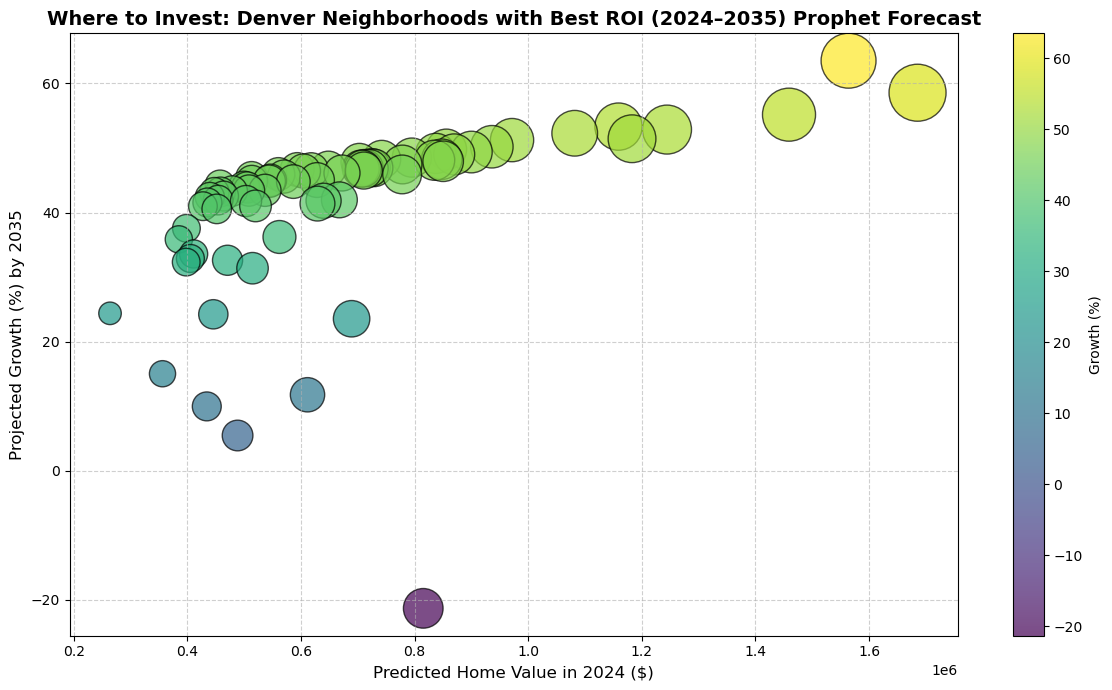

In [27]:

# Filter for best investment deals
price_median = growth_value_forecast[2024].median()
growth_threshold = growth__percent_forecast["10_Year_Growth_%"].quantile(0.75)

# Filter top deals
top_deals = (growth_value_forecast[2024] < price_median) & (growth__percent_forecast["10_Year_Growth_%"] > growth_threshold)


# Plot base scatter
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    growth_value_forecast[2024],
    growth__percent_forecast['10_Year_Growth_%'],
    s=growth_value_forecast[2024] / 1000,
    c=growth__percent_forecast['10_Year_Growth_%'],
    cmap="viridis",
    alpha=0.7,
    edgecolor="k"
)

# # Filter and prepare label list
# texts = []
# for _, row in top_deals.iterrows():
#     texts.append(
#         plt.text(
#             row["2024"],
#             row["Growth (%)"],
#             row["Neighborhood"],
#             fontsize=9,
#             weight="bold"
#         )
#     )

# Automatically adjust labels to prevent overlap
# adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=1))

# Final styling
plt.title("Where to Invest: Denver Neighborhoods with Best ROI (2024–2035) Prophet Forecast", fontsize=14, weight='bold')
plt.xlabel("Predicted Home Value in 2024 ($)", fontsize=12)
plt.ylabel("Projected Growth (%) by 2035", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.colorbar(scatter, label="Growth (%)")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


NameError: name 'X' is not defined